# Boca Juniors — Goalkeeper Scouting: Argentina & Brazil 2026

**Research question**

Boca Juniors currently has Leandro Brey as an internal goalkeeper option. Rather than assuming the club should necessarily go to the market, this project asks a more specific question:

> *Is there a clearly better goalkeeper option than Brey in Argentina or Brazil based on available 2026 basic goalkeeper metrics?*

The goal is not to make a definitive recruitment recommendation, but to build an **initial data-driven screening framework** (FBref, 2026 season).

---

**Data source:** FBref — *Standard* and *Advanced* goalkeeper table exports, Argentina and Brazil leagues 2026.  
The four expected CSV files are:
- `argentina_keepers_2026.csv`
- `argentina_keepers_advanced_2026.csv`
- `brazil_keepers_2026.csv`
- `brazil_keepers_advanced_2026.csv`

## 1. Data loading

In [ ]:
# CSV file loading
# Running on Google Colab: upload the 4 files when the selector appears
# Running locally: place the CSV files in the same directory as this notebook

import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import files
    print("Upload the 4 CSV files when the selector appears:")
    print("  - argentina_keepers_2026.csv")
    print("  - argentina_keepers_advanced_2026.csv")
    print("  - brazil_keepers_2026.csv")
    print("  - brazil_keepers_advanced_2026.csv")
    files.upload()
else:
    print("Local mode: make sure the 4 CSV files are in the working directory.")
    import os
    expected = [
        "argentina_keepers_2026.csv",
        "argentina_keepers_advanced_2026.csv",
        "brazil_keepers_2026.csv",
        "brazil_keepers_advanced_2026.csv",
    ]
    missing = [f for f in expected if not os.path.exists(f)]
    if missing:
        raise FileNotFoundError(f"Files not found: {missing}")
    print("\u2713 All 4 CSV files are present.")

Upload the 4 CSV files when the selector appears:
  - argentina_keepers_2026.csv
  - argentina_keepers_advanced_2026.csv
  - brazil_keepers_2026.csv
  - brazil_keepers_advanced_2026.csv


Saving brazil_keepers_2026.csv to brazil_keepers_2026.csv
Saving argentina_keepers_2026.csv to argentina_keepers_2026.csv
Saving brazil_keepers_advanced_2026.csv to brazil_keepers_advanced_2026.csv
Saving argentina_keepers_advanced_2026.csv to argentina_keepers_advanced_2026.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


def read_fbref_csv(file_name):
    """
    Reads a CSV exported from FBref.
    FBref inserts a repeated header row every few rows and uses tabs as
    the delimiter. This function normalises both issues.
    """
    df = pd.read_csv(
        file_name,
        sep="\t",
        skip_blank_lines=True,
        header=1
    )

    # Drop fully empty columns (FBref often exports a few)
    df = df.dropna(axis=1, how="all")

    # Remove repeated mid-table header rows
    if "Rk" in df.columns:
        df = df[df["Rk"] != "Rk"].copy()

    return df


arg_keepers     = read_fbref_csv("argentina_keepers_2026.csv")
arg_keepers_adv = read_fbref_csv("argentina_keepers_advanced_2026.csv")

bra_keepers     = read_fbref_csv("brazil_keepers_2026.csv")
bra_keepers_adv = read_fbref_csv("brazil_keepers_advanced_2026.csv")

## 2. Data cleaning and normalisation

In [ ]:
# Add league column before concatenating
arg_keepers["League"]     = "Argentina"
arg_keepers_adv["League"] = "Argentina"

bra_keepers["League"]     = "Brazil"
bra_keepers_adv["League"] = "Brazil"

In [ ]:
# Concatenate Argentina and Brazil into a single dataframe per table type
keepers     = pd.concat([arg_keepers, bra_keepers], ignore_index=True)
keepers_adv = pd.concat([arg_keepers_adv, bra_keepers_adv], ignore_index=True)

print("Basic keepers:", keepers.shape)
print("Advanced keepers:", keepers_adv.shape)

display(keepers.head())
display(keepers_adv.head())

Basic keepers: (82, 28)
Advanced keepers: (82, 35)


,Rk,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,GA,GA90,SoTA,Saves,Save%,W,D,L,CS,CS%,PKatt,PKA,PKsv,PKm,Save%.1,Matches,League
0,1,Alan Aguerre,ar ARG,GK,Cen. Córdoba–SdE,35-259,1990,16,16,"1,374",15.3,19,1.24,74,57,75.7,4,4,8,6,37.5,2,1,1,0,50.0,Matches,Argentina
1,2,Ignacio Arce,ar ARG,GK,Deportivo Riestra,34-031,1992,16,16,"1,440",16.0,12,0.75,64,55,85.9,1,8,7,6,37.5,3,3,0,0,0.0,Matches,Argentina
2,3,Gabriel Arias,cl CHI,GK,Newell's Old Boys,38-238,1987,7,7,612,6.8,13,1.91,32,20,62.5,0,2,5,0,0.0,1,1,0,0,0.0,Matches,Argentina
3,4,Franco Armani,ar ARG,GK,River Plate,39-205,1986,1,1,45,0.5,1,2.00,3,2,66.7,0,0,1,0,0.0,0,0,0,0,NaN,Matches,Argentina
4,5,Renzo Bacchia,uy URU,GK,Estudiantes–RC,27-106,1999,5,5,450,5.0,9,1.80,21,13,61.9,0,1,4,1,20.0,2,1,0,1,0.0,Matches,Argentina


,Rk,Player,Nation,Pos,Squad,Age,Born,90s,GA,PKA,FK,CK,OG,PSxG,PSxG/SoT,PSxG+/-,/90,Cmp,Att,Cmp%,Att (GK),Thr,Launch%,AvgLen,Att.1,Launch%.1,AvgLen.1,Opp,Stp,Stp%,#OPA,#OPA/90,AvgDist,Matches,League
0,1,Alan Aguerre,ar ARG,GK,Cen. Córdoba–SdE,35-259,1990,15.3,19,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Matches,Argentina
1,2,Ignacio Arce,ar ARG,GK,Deportivo Riestra,34-031,1992,16.0,12,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Matches,Argentina
2,3,Gabriel Arias,cl CHI,GK,Newell's Old Boys,38-238,1987,6.8,13,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Matches,Argentina
3,4,Franco Armani,ar ARG,GK,River Plate,39-205,1986,0.5,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Matches,Argentina
4,5,Renzo Bacchia,uy URU,GK,Estudiantes–RC,27-106,1999,5.0,9,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Matches,Argentina


In [ ]:
def clean_numeric_columns(df, exclude_cols=None):
    """
    Converts numeric columns exported by FBref:
    - Strips thousands separators (commas)
    - Strips the '%' symbol
    - Replaces the string 'nan' with real NaN
    - Attempts numeric parsing; leaves text columns untouched
    """
    if exclude_cols is None:
        exclude_cols = []

    df = df.copy()

    for col in df.columns:
        if col not in exclude_cols:
            df[col] = (
                df[col]
                .astype(str)
                .str.replace(",", "", regex=False)
                .str.replace("%", "", regex=False)
                .replace("nan", np.nan)
            )
            converted = pd.to_numeric(df[col], errors="coerce")
            # errors="ignore" was removed in pandas 2.0;
            # only apply the conversion if at least one value is numeric
            if converted.notna().any():
                df[col] = converted

    return df

In [ ]:
# Columns that must remain as text
text_cols = ["Player", "Nation", "Pos", "Squad", "Matches", "League"]

keepers     = clean_numeric_columns(keepers,     exclude_cols=text_cols)
keepers_adv = clean_numeric_columns(keepers_adv, exclude_cols=text_cols)

/tmp/ipykernel_16827/944253886.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace("nan", np.nan)
/tmp/ipykernel_16827/944253886.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace("nan", np.nan)
/tmp/ipykernel_16827/944253886.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .rep

In [ ]:
# Rename ambiguous columns in the basic dataframe
keepers = keepers.rename(columns={
    "Save%":   "Save_pct",
    "Save%.1": "PK_Save_pct",
    "CS%":     "CS_pct",
    "90s":     "Nineties"
})

In [ ]:
def extract_age_years(age_value):
    """
    FBref encodes age as 'years-days' (e.g. '28-210').
    This function extracts only the year component as an integer.
    """
    if pd.isna(age_value):
        return np.nan
    return pd.to_numeric(str(age_value).split("-")[0], errors="coerce")


keepers["Age_years"]     = keepers["Age"].apply(extract_age_years)
keepers_adv["Age_years"] = keepers_adv["Age"].apply(extract_age_years)

## 3. Data integration and quality check

In [ ]:
# Merge basic and advanced tables on player, club, and league
gk_data = keepers.merge(
    keepers_adv,
    on=["Player", "Squad", "League"],
    how="inner",
    suffixes=("_basic", "_adv")
)

print("Merged dataset:", gk_data.shape)
display(gk_data.head())

Merged dataset: (82, 62)


,Rk_basic,Player,Nation_basic,Pos_basic,Squad,Age_basic,Born_basic,MP,Starts,Min,Nineties,GA_basic,GA90,SoTA,Saves,Save_pct,W,D,L,CS,CS_pct,PKatt,PKA_basic,PKsv,PKm,PK_Save_pct,Matches_basic,League,Age_years_basic,Rk_adv,Nation_adv,Pos_adv,Age_adv,Born_adv,90s,GA_adv,PKA_adv,FK,CK,OG,PSxG,PSxG/SoT,PSxG+/-,/90,Cmp,Att,Cmp%,Att (GK),Thr,Launch%,AvgLen,Att.1,Launch%.1,AvgLen.1,Opp,Stp,Stp%,#OPA,#OPA/90,AvgDist,Matches_adv,Age_years_adv
0,1,Alan Aguerre,ar ARG,GK,Cen. Córdoba–SdE,35-259,1990,16,16,1374,15.3,19,1.24,74,57,75.7,4,4,8,6,37.5,2,1,1,0,50.0,Matches,Argentina,35,1,ar ARG,GK,35-259,1990,15.3,19,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Matches,35
1,2,Ignacio Arce,ar ARG,GK,Deportivo Riestra,34-031,1992,16,16,1440,16.0,12,0.75,64,55,85.9,1,8,7,6,37.5,3,3,0,0,0.0,Matches,Argentina,34,2,ar ARG,GK,34-031,1992,16.0,12,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Matches,34
2,3,Gabriel Arias,cl CHI,GK,Newell's Old Boys,38-238,1987,7,7,612,6.8,13,1.91,32,20,62.5,0,2,5,0,0.0,1,1,0,0,0.0,Matches,Argentina,38,3,cl CHI,GK,38-238,1987,6.8,13,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Matches,38
3,4,Franco Armani,ar ARG,GK,River Plate,39-205,1986,1,1,45,0.5,1,2.00,3,2,66.7,0,0,1,0,0.0,0,0,0,0,NaN,Matches,Argentina,39,4,ar ARG,GK,39-205,1986,0.5,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Matches,39
4,5,Renzo Bacchia,uy URU,GK,Estudiantes–RC,27-106,1999,5,5,450,5.0,9,1.80,21,13,61.9,0,1,4,1,20.0,2,1,0,1,0.0,Matches,Argentina,27,5,uy URU,GK,27-106,1999,5.0,9,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Matches,27


In [ ]:
# Rename advanced-table columns for clarity
gk_data = gk_data.rename(columns={
    "90s":          "Nineties_adv",
    "PSxG+/-":      "PSxG_minus_GA",
    "/90":          "PSxG_minus_GA_per90",
    "PSxG/SoT":     "PSxG_per_SoT",
    "Cmp%":         "Pass_Cmp_pct",
    "Att":          "Pass_Att",
    "Cmp":          "Pass_Cmp",
    "Att (GK)":     "GK_Pass_Att",
    "Thr":          "Throws",
    "Launch%":      "Launch_pct",
    "AvgLen":       "Avg_Pass_Length",
    "Att.1":        "GoalKick_Att",
    "Launch%.1":    "GoalKick_Launch_pct",
    "AvgLen.1":     "GoalKick_Avg_Length",
    "Stp%":         "Cross_Stop_pct",
    "#OPA":         "OPA",
    "#OPA/90":      "OPA_per90",
    "AvgDist":      "Avg_Def_Action_Distance"
})

In [ ]:
# Check dtypes for the columns used in the model
cols_to_check = [
    "Age_years_basic",
    "Min",
    "Nineties",
    "GA90",
    "SoTA",
    "Saves",
    "Save_pct",
    "CS_pct",
    "PSxG",
    "PSxG_minus_GA",
    "PSxG_minus_GA_per90",
    "Pass_Cmp_pct",
    "Launch_pct",
    "GoalKick_Launch_pct",
    "Cross_Stop_pct",
    "OPA_per90",
    "Avg_Def_Action_Distance"
]

gk_data[cols_to_check].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age_years_basic          82 non-null     int64  
 1   Min                      82 non-null     int64  
 2   Nineties                 82 non-null     float64
 3   GA90                     82 non-null     float64
 4   SoTA                     82 non-null     int64  
 5   Saves                    82 non-null     int64  
 6   Save_pct                 82 non-null     float64
 7   CS_pct                   80 non-null     float64
 8   PSxG                     0 non-null      float64
 9   PSxG_minus_GA            0 non-null      float64
 10  PSxG_minus_GA_per90      0 non-null      float64
 11  Pass_Cmp_pct             0 non-null      float64
 12  Launch_pct               0 non-null      float64
 13  GoalKick_Launch_pct      0 non-null      float64
 14  Cross_Stop_pct           0 n

In [ ]:
# Percentage of missing values per column
missing_summary = gk_data.isna().mean().sort_values()

display(
    pd.DataFrame({"missing_pct": missing_summary})
    .style.format({"missing_pct": "{:.1%}"})
)

,missing_pct
Rk_basic,0.0%
Player,0.0%
Nation_basic,0.0%
Pos_basic,0.0%
Squad,0.0%
Age_basic,0.0%
Born_basic,0.0%
MP,0.0%
Starts,0.0%
Min,0.0%


## 4. Candidate filtering

Two minimum filters are applied to ensure a representative sample:

- **Age ≤ 34**: excludes goalkeepers in the final stage of their career.
- **Minutes played ≥ 300**: equivalent to ~3.3 full matches; removes goalkeepers with no meaningful playing time.

In [ ]:
basic_candidates = gk_data[
    (gk_data["Age_years_basic"] <= 34) &
    (gk_data["Min"] >= 300)
].copy()

print("Number of candidates:", basic_candidates.shape[0])

display(
    basic_candidates[[
        "Player", "Squad", "League", "Age_years_basic", "Min",
        "GA90", "SoTA", "Saves", "Save_pct", "CS_pct"
    ]]
    .sort_values("Min", ascending=False)
)

Number of candidates: 42


,Player,Squad,League,Age_years_basic,Min,GA90,SoTA,Saves,Save_pct,CS_pct
1,Ignacio Arce,Deportivo Riestra,Argentina,34,1440,0.75,64,55,85.9,37.5
8,Matías Borgogno,Platense,Argentina,27,1440,0.94,64,50,78.1,37.5
14,Thiago Cardozo,Belgrano,Argentina,29,1440,0.81,55,45,81.8,50.0
16,Brayan Cortés,Arg Juniors,Argentina,31,1440,0.81,43,30,69.8,50.0
13,Facundo Cambeses,Racing Club,Argentina,29,1440,0.94,53,38,71.7,37.5
44,Facundo Sanguinetti,Banfield,Argentina,25,1440,1.19,84,67,79.8,25.0
24,Guido Herrera,Talleres–C,Argentina,34,1440,0.81,58,46,79.3,37.5
26,Luis Ingolotti,Atlé Tucumán,Argentina,26,1440,1.25,49,32,63.3,31.3
20,Cristopher Fiermarin,Defensa y Justicia,Argentina,28,1440,1.31,58,40,67.2,31.3
17,Álvaro David Montero,Vélez Sarsfield,Argentina,31,1440,0.75,77,65,84.4,43.8


In [ ]:
# Per-90 metrics are computed in the scoring cell (section 5)
# to ensure they are available on score_data without relying on
# pandas persisting the assignment on an intermediate copy.

## 5. Scoring model: Boca GK Score v1

A composite index is built using the metrics most relevant to a goalkeeper
in Boca Juniors' style of play. All variables are scaled to [0, 1] with
MinMaxScaler before applying the weights.

| Metric | Weight | Direction | Rationale |
|---|---|---|---|
| `Save_pct` | 45% | Higher = better | Primary shot-stopping performance indicator |
| `GA90` | 20% | Lower = better | Goals conceded per 90 min; inverted for the score |
| `CS_pct` | 15% | Higher = better | Clean sheet percentage |
| `Min` | 10% | Higher = better | Rewards consistency and coach trust |
| `Saves_per90` | 5% | Higher = better | Actual workload volume |
| Age profile | 5% | Peak at 24–31 | Slight penalty for profiles outside that range |

> **Note:** this model relies exclusively on basic metrics available on FBref.
> A future version could incorporate PSxG+/- and distribution metrics for greater robustness.

In [ ]:
score_data = basic_candidates.copy()

# Compute per-90 metrics directly on score_data
score_data["Saves_per90"] = score_data["Saves"] / score_data["Nineties"]
score_data["SoTA_per90"]  = score_data["SoTA"]  / score_data["Nineties"]

# Ensure numeric dtype and impute medians for scoring columns
score_cols = ["Save_pct", "GA90", "CS_pct", "Min", "Saves_per90"]

for col in score_cols:
    score_data[col] = pd.to_numeric(score_data[col], errors="coerce")
    score_data[col] = score_data[col].fillna(score_data[col].median())

scaler = MinMaxScaler()

score_data["Save_pct_score"]    = scaler.fit_transform(score_data[["Save_pct"]])
score_data["CS_pct_score"]      = scaler.fit_transform(score_data[["CS_pct"]])
score_data["Min_score"]         = scaler.fit_transform(score_data[["Min"]])
score_data["Saves_per90_score"] = scaler.fit_transform(score_data[["Saves_per90"]])

# GA90: lower is better → invert
score_data["GA90_score"] = 1 - scaler.fit_transform(score_data[["GA90"]])

# Age profile: peak score for the 24–31 range, linear decay outside it
score_data["Age_profile_score"] = score_data["Age_years_basic"].apply(
    lambda age: 1 if 24 <= age <= 31 else max(0, 1 - abs(age - 27.5) / 10)
)

score_data["Boca_GK_Score_v1"] = (
    0.45 * score_data["Save_pct_score"]    +
    0.20 * score_data["GA90_score"]        +
    0.15 * score_data["CS_pct_score"]      +
    0.10 * score_data["Min_score"]         +
    0.05 * score_data["Saves_per90_score"] +
    0.05 * score_data["Age_profile_score"]
)

In [ ]:
# Full candidate ranking
shortlist_v1 = score_data.sort_values("Boca_GK_Score_v1", ascending=False)

shortlist_display = shortlist_v1[[
    "Player", "Squad", "League", "Age_years_basic", "Min",
    "GA90", "SoTA", "Saves", "Saves_per90",
    "Save_pct", "CS_pct", "Boca_GK_Score_v1"
]].copy()

shortlist_display = shortlist_display.round({
    "GA90":             2,
    "Saves_per90":      2,
    "Save_pct":         1,
    "CS_pct":           1,
    "Boca_GK_Score_v1": 3
})

display(shortlist_display.head(20))

,Player,Squad,League,Age_years_basic,Min,GA90,SoTA,Saves,Saves_per90,Save_pct,CS_pct,Boca_GK_Score_v1
9,Leandro Brey,Boca Juniors,Argentina,23,369,0.24,10,9,2.20,90.0,100.0,0.839
25,Fabricio Iacovich,Estudiantes–LP,Argentina,24,495,0.36,19,18,3.27,89.5,60.0,0.805
17,Álvaro David Montero,Vélez Sarsfield,Argentina,31,1440,0.75,77,65,4.06,84.4,43.8,0.760
22,Orlando Gill,San Lorenzo,Argentina,25,1260,0.79,61,50,3.57,83.6,64.3,0.753
1,Ignacio Arce,Deportivo Riestra,Argentina,34,1440,0.75,64,55,3.44,85.9,37.5,0.732
14,Thiago Cardozo,Belgrano,Argentina,29,1440,0.81,55,45,2.81,81.8,50.0,0.710
36,Marcelo Miño,Barracas Central,Argentina,28,979,0.83,58,49,4.50,84.5,27.3,0.692
72,Ronaldo,Bahia,Brazil,29,584,0.62,23,19,2.92,82.6,42.9,0.656
6,Santiago Beltrán,River Plate,Argentina,21,1395,0.71,46,37,2.39,80.4,46.7,0.654
63,Carlos Miguel,Palmeiras,Brazil,27,1260,0.79,53,42,3.00,79.2,35.7,0.639


## 6. Results

In [ ]:
# Final table of top candidates
final_table = shortlist_v1[[
    "Player", "Squad", "League", "Age_years_basic", "Min",
    "GA90", "Save_pct", "CS_pct", "Saves_per90",
    "Boca_GK_Score_v1"
]].copy()

final_table = final_table.rename(columns={
    "Squad":            "Club",
    "Age_years_basic":  "Age",
    "Min":              "Minutes",
    "GA90":             "GA/90",
    "Save_pct":         "Save %",
    "CS_pct":           "Clean Sheet %",
    "Saves_per90":      "Saves/90",
    "Boca_GK_Score_v1": "Boca GK Score"
})

final_table = final_table.round({
    "GA/90":         2,
    "Save %":        1,
    "Clean Sheet %": 1,
    "Saves/90":      2,
    "Boca GK Score": 3
})

display(final_table.head(12))

,Player,Club,League,Age,Minutes,GA/90,Save %,Clean Sheet %,Saves/90,Boca GK Score
9,Leandro Brey,Boca Juniors,Argentina,23,369,0.24,90.0,100.0,2.20,0.839
25,Fabricio Iacovich,Estudiantes–LP,Argentina,24,495,0.36,89.5,60.0,3.27,0.805
17,Álvaro David Montero,Vélez Sarsfield,Argentina,31,1440,0.75,84.4,43.8,4.06,0.760
22,Orlando Gill,San Lorenzo,Argentina,25,1260,0.79,83.6,64.3,3.57,0.753
1,Ignacio Arce,Deportivo Riestra,Argentina,34,1440,0.75,85.9,37.5,3.44,0.732
14,Thiago Cardozo,Belgrano,Argentina,29,1440,0.81,81.8,50.0,2.81,0.710
36,Marcelo Miño,Barracas Central,Argentina,28,979,0.83,84.5,27.3,4.50,0.692
72,Ronaldo,Bahia,Brazil,29,584,0.62,82.6,42.9,2.92,0.656
6,Santiago Beltrán,River Plate,Argentina,21,1395,0.71,80.4,46.7,2.39,0.654
63,Carlos Miguel,Palmeiras,Brazil,27,1260,0.79,79.2,35.7,3.00,0.639


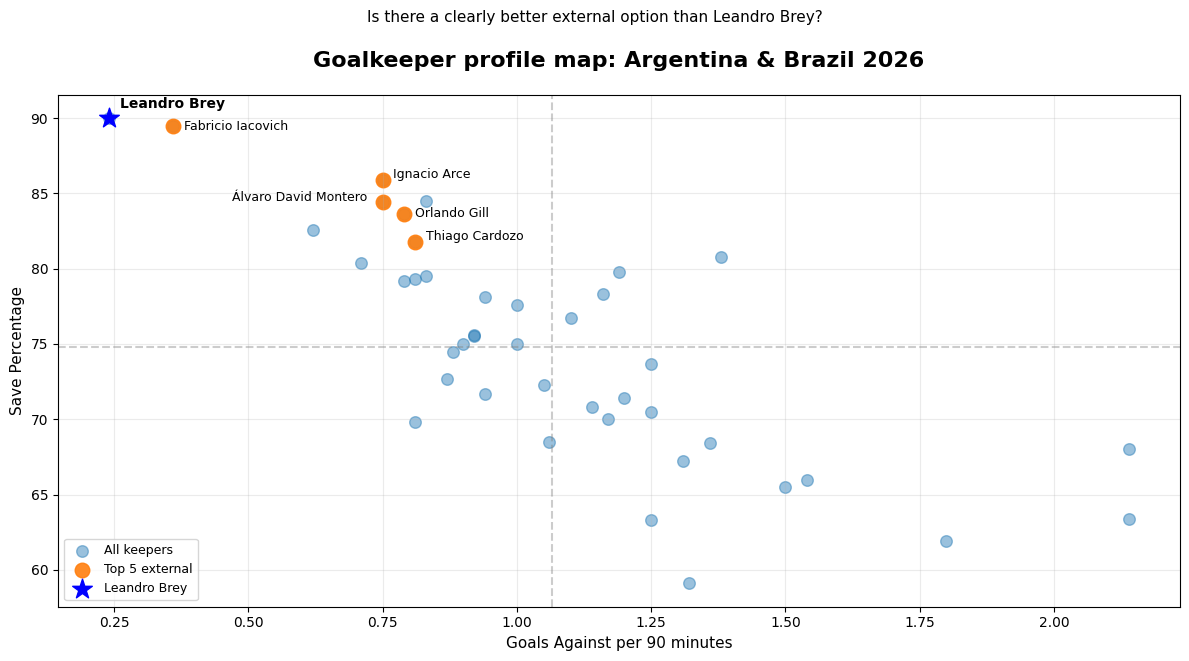

In [ ]:
# Profile map: Save % vs GA/90
# Orange dots = top 5 external candidates; blue star = Leandro Brey
plot_data = score_data.copy()

top_players = (
    plot_data[~plot_data["Player"].str.contains("Brey", case=False, na=False)]
    .sort_values("Boca_GK_Score_v1", ascending=False)
    .head(5)
)
brey_data = plot_data[plot_data["Player"].str.contains("Brey", case=False, na=False)]

avg_ga90 = plot_data["GA90"].mean()
avg_save = plot_data["Save_pct"].mean()

plt.figure(figsize=(12, 7))

plt.scatter(plot_data["GA90"], plot_data["Save_pct"], alpha=0.45, s=70, label="All keepers")
plt.scatter(top_players["GA90"], top_players["Save_pct"], alpha=0.9, s=110, label="Top 5 external")

if not brey_data.empty:
    plt.scatter(
        brey_data["GA90"], brey_data["Save_pct"],
        s=220, marker="*", color="blue", label="Leandro Brey", zorder=5
    )

plt.axvline(avg_ga90, linestyle="--", alpha=0.4, color="gray")
plt.axhline(avg_save, linestyle="--", alpha=0.4, color="gray")

# Manual offsets to avoid label overlap
offsets = [(0.02, -0.3), (-0.28, 0.1), (0.02, -0.15), (0.02, 0.1), (0.02, 0.1)]

for (_, row), (dx, dy) in zip(top_players.iterrows(), offsets):
    plt.text(row["GA90"] + dx, row["Save_pct"] + dy, row["Player"], fontsize=9)

if not brey_data.empty:
    brey_row = brey_data.iloc[0]
    plt.text(
        brey_row["GA90"] + 0.02, brey_row["Save_pct"] + 0.7,
        "Leandro Brey", fontsize=10, fontweight="bold"
    )

plt.xlabel("Goals Against per 90 minutes", fontsize=11)
plt.ylabel("Save Percentage", fontsize=11)
plt.title("Goalkeeper profile map: Argentina & Brazil 2026", fontsize=16, fontweight="bold", pad=20)
plt.figtext(0.5, 0.92, "Is there a clearly better external option than Leandro Brey?", ha="center", fontsize=11)
plt.legend(loc="lower left", fontsize=9)
plt.grid(True, alpha=0.25)
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

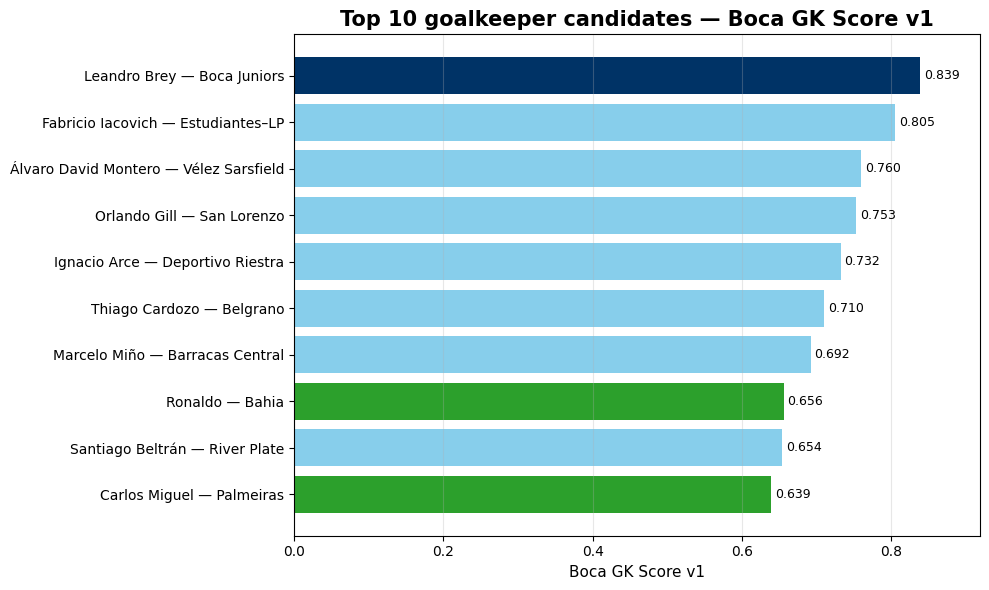

In [ ]:
# Visual ranking: Top 10 keepers by Boca GK Score v1
# Colours: dark blue = Brey, green = Brazil, light blue = Argentina
top_10 = shortlist_v1.head(10).sort_values("Boca_GK_Score_v1")
labels = top_10["Player"] + " — " + top_10["Squad"]
values = top_10["Boca_GK_Score_v1"]

colors = [
    "#003366" if "Brey" in row["Player"]
    else "#2ca02c" if row["League"] == "Brazil"
    else "#87ceeb"
    for _, row in top_10.iterrows()
]

plt.figure(figsize=(10, 6))
bars = plt.barh(labels, values, color=colors)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height() / 2, f"{width:.3f}", va="center", fontsize=9)

plt.xlabel("Boca GK Score v1", fontsize=11)
plt.title("Top 10 goalkeeper candidates — Boca GK Score v1", fontsize=15, fontweight="bold")
plt.grid(axis="x", alpha=0.3)
plt.xlim(0, values.max() + 0.08)
plt.tight_layout()
plt.show()

## 8. Conclusion

Based on the Boca GK Score v1, no external goalkeeper from Argentina or Brazil appears to be clearly better than Leandro Brey.

Brey ranks first in the model, with a score of **0.839**. The closest external candidate is Fabricio Iacovich, with **0.805**, followed by Álvaro David Montero, Orlando Gill and Ignacio Arce.

This result should not be interpreted as a definitive scouting conclusion. Brey has a smaller sample size than several other candidates, and the model does not fully adjust for team context, league strength, tactical role, contract situation or qualitative scouting information.

However, as an initial data-driven screening exercise, the evidence does not point to an obvious external upgrade over Brey in Argentina or Brazil.

The practical conclusion is that Boca may still monitor the market, but the data does not strongly support the idea that there is a clearly superior available profile based only on the selected 2026 goalkeeper metrics.